# **Testing the statistics of the Data for both Solar and Wind**

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

solar_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/solar_cf"
wind_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/wind_cf"

# directory of netCDFs → open them all as one dataset
ds_solar = xr.open_mfdataset(f"{solar_cf_path}/*.nc")
ds_wind = xr.open_mfdataset(f"{wind_cf_path}/*.nc")
print(ds_solar)
print(ds_wind)

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


<xarray.Dataset> Size: 75GB
Dimensions:          (time: 736337, lat: 141, lon: 181)
Coordinates:
  * time             (time) datetime64[ns] 6MB 1940-01-01T07:00:00 ... 2023-1...
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
Data variables:
    capacity_factor  (time, lat, lon) float32 75GB dask.array<chunksize=(8777, 141, 181), meta=np.ndarray>
<xarray.Dataset> Size: 75GB
Dimensions:          (time: 736344, lat: 141, lon: 181)
Coordinates:
  * time             (time) datetime64[ns] 6MB 1940-01-01 ... 2023-12-31T23:0...
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
Data variables:
    capacity_factor  (time, lat, lon) float32 75GB dask.array<chunksize=(8784, 141, 181), meta=np.ndarray>


In [2]:
var = 'capacity_factor'

WINTER = [5, 6, 7, 8, 9]

def winter_daily(ds, var=var):
    daily = ds[var].resample(time='1D').mean()
    return daily.sel(time=daily.time.dt.month.isin(WINTER))

solar_daily = winter_daily(ds_solar)
wind_daily  = winter_daily(ds_wind)

solar_daily, wind_daily = xr.align(solar_daily, wind_daily, join='inner')

with ProgressBar():
    solar_daily = solar_daily.load()
    wind_daily  = wind_daily.load()

print(solar_daily)
print(wind_daily)



<xarray.DataArray 'capacity_factor' (time: 12852, lat: 141, lon: 181)> Size: 1GB
array([[[0.22322328, 0.21584022, 0.2151683 , ..., 0.2000221 ,
         0.19956146, 0.20122057],
        [0.22837953, 0.2226352 , 0.2220915 , ..., 0.19967096,
         0.19777691, 0.20054263],
        [0.23199861, 0.22729117, 0.22582437, ..., 0.20251407,
         0.20260017, 0.20386976],
        ...,
        [0.08738547, 0.08716062, 0.08646258, ..., 0.0766772 ,
         0.0853416 , 0.09253594],
        [0.08421287, 0.08486596, 0.08493551, ..., 0.07037253,
         0.07854883, 0.08603852],
        [0.07990711, 0.08240955, 0.0841825 , ..., 0.06526156,
         0.07183532, 0.07934333]],

       [[0.20497568, 0.20669639, 0.20666891, ..., 0.20490551,
         0.2022605 , 0.20044267],
        [0.21071492, 0.2107774 , 0.20990233, ..., 0.20367175,
         0.20022207, 0.19762935],
        [0.21401136, 0.21366383, 0.2124306 , ..., 0.20229478,
         0.1995669 , 0.1969899 ],
...
        [0.20616823, 0.2020579 , 0

In [3]:
q = 0.10

# per-cell winter thresholds
solar_thr = solar_daily.quantile(q, dim='time').drop_vars('quantile')
wind_thr = wind_daily.quantile(q, dim='time').drop_vars('quantile')

# Lull masks (cell x day) and co-occurrence
solar_lull = solar_daily < solar_thr
wind_lull = wind_daily < wind_thr
both_lull = solar_lull & wind_lull

# per-cell statistics 
p_s = solar_lull.mean('time')
p_w = wind_lull.mean('time')
p_both = both_lull.mean('time')
co_occurrence_ratio = p_both / (p_s * p_w)
p_w_given_s = p_both / p_s
p_s_given_w = p_both / p_w

print(f"mean P(both): {float(p_both.mean()):.4f} (independence = {float((p_s*p_w).mean()):.4f})")
print(f"mean co-occurrence: {float(co_occurrence_ratio.mean()):.2f}")
print(f"marginal check - solar {float(p_s.mean()):.3f}, wind {float(p_w.mean()):.3f}")

mean P(both): 0.0099 (independence = 0.0099)
mean co-occurrence: 1.00
marginal check - solar 0.100, wind 0.099


In [6]:
print(f"co-occurrence: mean {float(co_occurrence_ratio.mean()):.2f}, std {float(co_occurrence_ratio.std()):.2f}, "
      f"min {float(co_occurrence_ratio.min()):.2f}, max {float(co_occurrence_ratio.max()):.2f}")

exp_joint = 12852 * float((p_s * p_w).mean())
print(f"expected joint days/cell ≈ {exp_joint:.0f}, "
      f"noise floor on co-occurrence ≈ {1/np.sqrt(exp_joint):.2f}")


co-occurrence: mean 1.00, std 0.52, min 0.09, max 3.50
expected joint days/cell ≈ 127, noise floor on co-occurrence ≈ 0.09


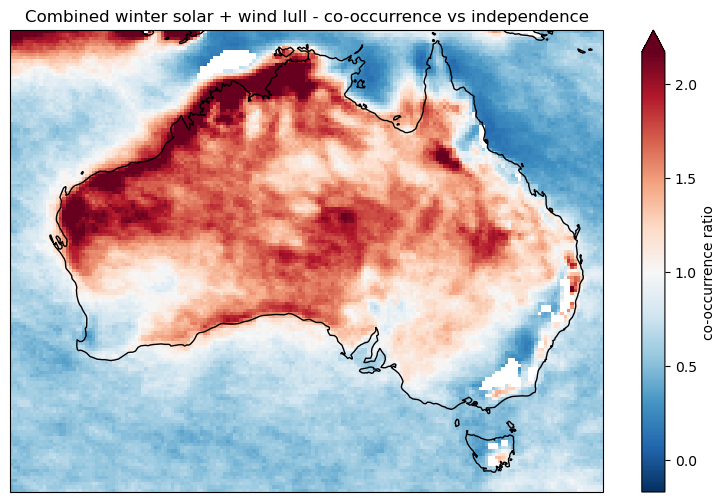

In [17]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
co_occurrence_ratio.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='RdBu_r', center=1, robust=True,
                         cbar_kwargs={'label': 'co-occurrence ratio'})
ax.add_feature(cfeature.COASTLINE)
ax.set_title('Combined winter solar + wind lull - co-occurrence vs independence')
plt.show()

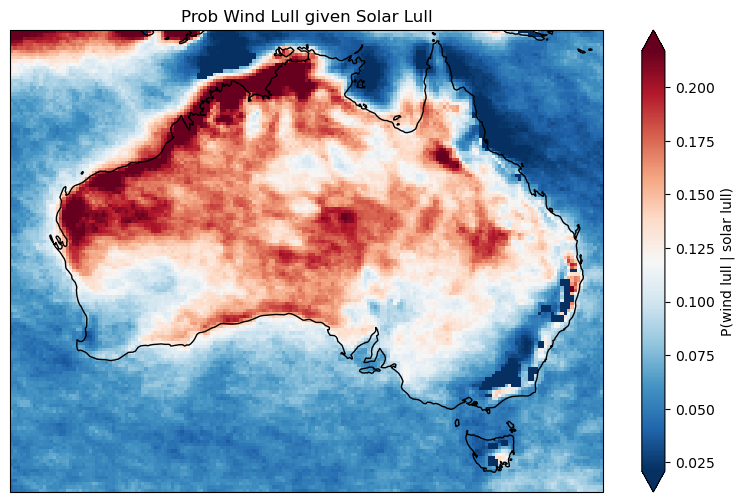

In [24]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p_w_given_s.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='RdBu_r', robust=True,
                         cbar_kwargs={'label': 'P(wind lull | solar lull)'})
ax.add_feature(cfeature.COASTLINE)
ax.set_title('Prob Wind Lull given Solar Lull')
plt.show()

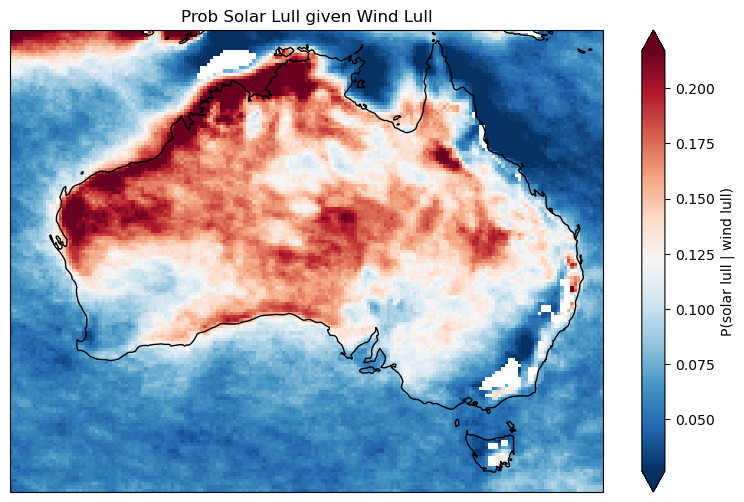

In [23]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p_s_given_w.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='RdBu_r', robust=True,
                         cbar_kwargs={'label': 'P(solar lull | wind lull)'})
ax.add_feature(cfeature.COASTLINE)
ax.set_title('Prob Solar Lull given Wind Lull')
plt.show()

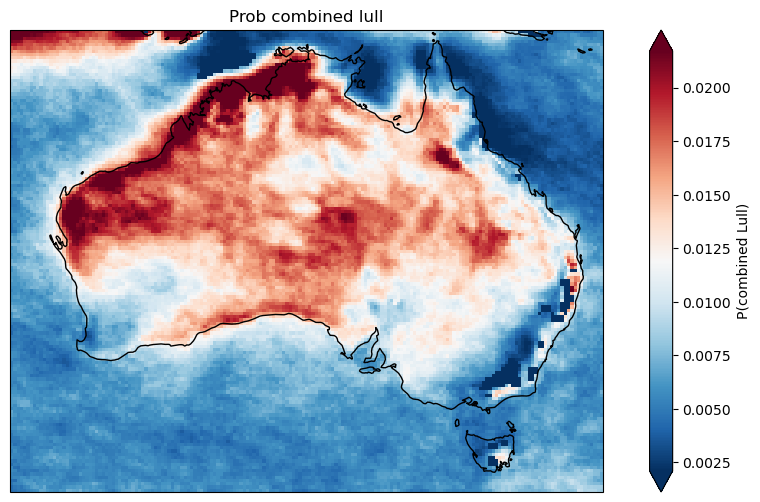

In [22]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p_both.plot(ax=ax, transform=ccrs.PlateCarree(),
                         cmap='RdBu_r', robust=True,
                         cbar_kwargs={'label': 'P(combined Lull)'})
ax.add_feature(cfeature.COASTLINE)
ax.set_title('Prob combined lull')
plt.show()

# **Bringing in Weather Feautres**

In [10]:
import glob, numpy as np, xarray as xr

# parent folder, NOT the /1979 subfolder
fronts_root = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/weatherfeatures/fronts/cdf.700hPa"
all_nc = sorted(glob.glob(f"{fronts_root}/**/*.nc", recursive=True))   # ** = recurse into year subfolders
print("files matched:", len(all_nc))          # expect ~528 (44 yrs × 12 months)

lat = np.linspace(90, -90, 361)                # flip to (-90, 90, 361) if the orientation check fails
lon = np.linspace(0, 359.5, 720)

def prep(ds):                                  # runs on each file before concatenation
    ds = (ds.squeeze('dimz_INPUT', drop=True)
            .rename({'dimy_INPUT': 'lat', 'dimx_INPUT': 'lon'})
            .assign_coords(lat=lat, lon=lon)[['FRONT', 'TYPE']]   # attach coords, drop TGRAD
            .sortby('lat'))
    return ds.sel(lat=slice(-50, -8), lon=slice(100, 160))        # crop to an Australia box

ds_fronts = xr.open_mfdataset(all_nc, preprocess=prep,
                              combine='by_coords', parallel=True,
                              chunks={'time': 744})
print("span:", ds_fronts.time.values[[0, -1]], "| steps:", ds_fronts.time.size)

# sanity checks
s = ds_fronts.isel(time=slice(0, 240))
print("FRONT range:", float(s.FRONT.min()), float(s.FRONT.max()))
print("TYPE values:", np.unique(s.TYPE.values))

files matched: 528
span: ['1979-01-01T00:00:00.000000000' '2022-12-31T23:00:00.000000000'] | steps: 385702
FRONT range: 0.0 1.0
TYPE values: [0. 1. 2. 3.]


In [11]:
bl = both_lull.sel(time=slice('1979', '2022'))
frac = bl.mean(['lat', 'lon']).compute()
worst = frac.to_series().sort_values(ascending=False)
print(worst.head(10))
event_date = worst.index[0]

time
2010-05-16    0.133615
2005-07-12    0.122017
2016-06-05    0.120019
1995-06-14    0.119509
1986-06-28    0.115944
2015-06-15    0.112378
2016-07-07    0.112260
1992-06-14    0.111046
2010-05-20    0.110536
1986-06-20    0.109635
Name: capacity_factor, dtype: float64


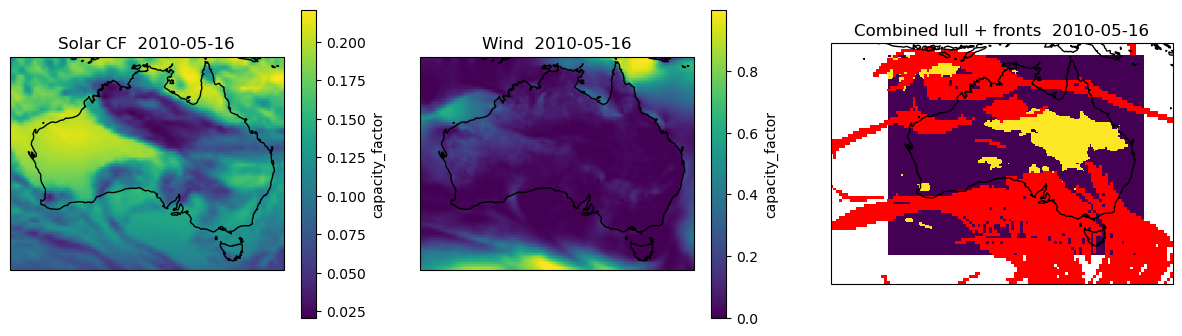

In [13]:
import matplotlib.colors as mcolors

# event_date is a full timestamp, slice off just the 'YYYY-MM-DD' part so we can select a whole calendar day by name
day = str(event_date)[:10]

# Make one row of 3 maps
fig, axs = plt.subplots(1, 3, figsize=(15, 4),
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Panel 0: solar capacity factor on the chosen day
solar_daily.sel(time=day).plot(ax=axs[0], transform=ccrs.PlateCarree())

# Panel 1: wind capacity factor on the same day
wind_daily.sel(time=day).plot(ax=axs[1], transform=ccrs.PlateCarree())

# Panel 2: the combined-lull footprint 
bl.sel(time=day).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False)

# Add the fronts on top of panel 2
fr_day = (ds_fronts.FRONT.sel(time=day) > 0).max('time')

# fr_day.where(fr_day) keeps the cells that had a front (True) and blanks the rest to NaN
fr_day.where(fr_day).plot.pcolormesh(ax=axs[2], transform=ccrs.PlateCarree(),
                                  cmap=mcolors.ListedColormap(['red']), add_colorbar=False)

for ax, t in zip(axs, ['Solar CF', 'Wind', 'Combined lull + fronts']):
    ax.coastlines()
    ax.set_title(f'{t}  {day}')

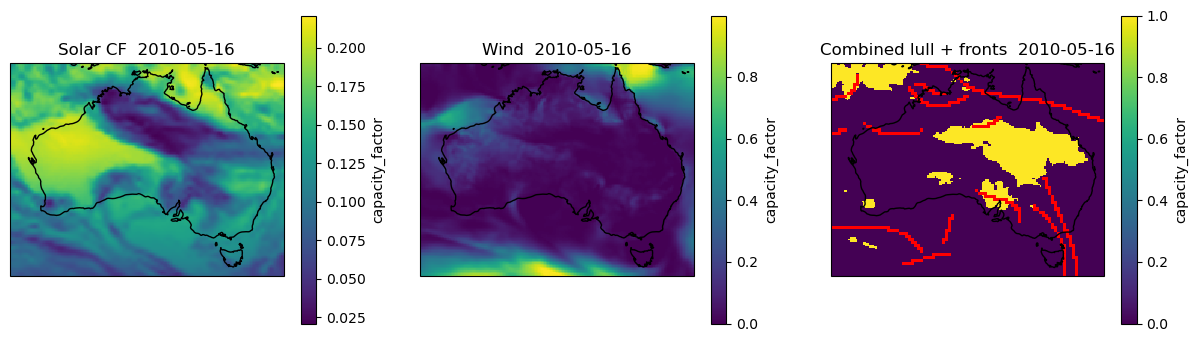

In [15]:
import matplotlib.colors as mcolors

# event_date is a full timestamp; slice off the 'YYYY-MM-DD' part to select a whole day by name
day = str(event_date)[:10]

# Make one row of 3 maps
fig, axs = plt.subplots(1, 3, figsize=(15, 4),
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Panel 0: solar capacity factor on the chosen day
solar_daily.sel(time=day).plot(ax=axs[0], transform=ccrs.PlateCarree())
# Panel 1: wind capacity factor on the same day
wind_daily.sel(time=day).plot(ax=axs[1], transform=ccrs.PlateCarree())
# Panel 2: the combined-lull footprint
bl.sel(time=day).plot(ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=True)

# Add the fronts on top of panel 2 — a SINGLE hour (00Z) so they show as lines, not a smeared swath
fr_hr = (ds_fronts.FRONT.sel(time=day).isel(time=0) > 0)
fr_hr.where(fr_hr).plot.pcolormesh(ax=axs[2], transform=ccrs.PlateCarree(),
                                   cmap=mcolors.ListedColormap(['red']), add_colorbar=False)
axs[2].set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())   # crop so red doesn't spill past the data

for ax, t in zip(axs, ['Solar CF', 'Wind', 'Combined lull + fronts']):
    ax.coastlines()
    ax.set_title(f'{t}  {day}')